# Non-Linear Feature Engineering for Linear Regression
Even if a model is not natively adapted to express a target that is not a linear function of the features, it is possible to make linear models more expressive by engineering additional features.

For the sake of example, we are generating a single feature dataset represented by a cubic polynomial with some noise.

In [3]:
import numpy as np
from scipy.stats import alpha
from sklearn.metrics import mean_squared_error

rng = np.random.RandomState(0)

n_sample = 100
data_max, data_min = 1.4, -1.4
len_data = data_max - data_min

data = np.sort(rng.rand(n_sample) * len_data - len_data / 2)
noise = rng.randn(n_sample) * 0.3
target = data ** 3 - 0.5 * data ** 2 + noise

In [4]:
import pandas as pd

full_data = pd.DataFrame({
    "input_feature": data,
    "target": target
})

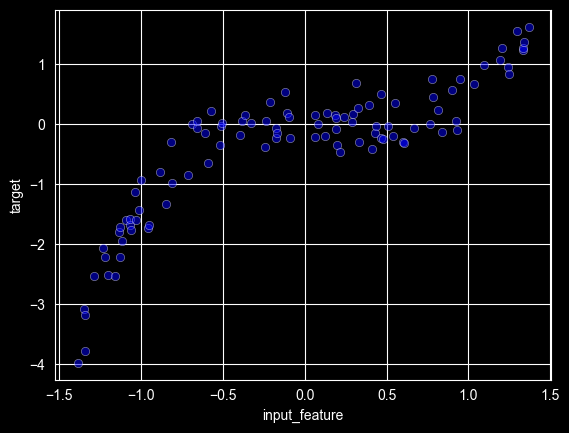

In [5]:
import seaborn as sns

_ = sns.scatterplot(
    data=full_data,
    x="input_feature",
    y="target",
    color="blue",
    alpha=0.5
)

In scikit-learn, the `X` data needs to be represented by a 2D matrix.

In [6]:
data = data.reshape((-1, 1))
data.shape

(100, 1)

In [7]:
data

array([[-1.38685267],
       [-1.34738856],
       [-1.34369887],
       [-1.34338849],
       [-1.29027418],
       [-1.23136868],
       [-1.22038701],
       [-1.20109904],
       [-1.15603796],
       [-1.13696657],
       [-1.13092446],
       [-1.12811643],
       [-1.11427453],
       [-1.0909496 ],
       [-1.06883161],
       [-1.06756239],
       [-1.06344963],
       [-1.03900637],
       [-1.03096599],
       [-1.01308774],
       [-0.9986108 ],
       [-0.95488517],
       [-0.94833335],
       [-0.88706419],
       [-0.84956939],
       [-0.81514508],
       [-0.81092883],
       [-0.71560834],
       [-0.69078351],
       [-0.65924429],
       [-0.65690943],
       [-0.6081405 ],
       [-0.58966294],
       [-0.57080745],
       [-0.51680062],
       [-0.5096471 ],
       [-0.50800693],
       [-0.39337788],
       [-0.38160984],
       [-0.36756952],
       [-0.32636375],
       [-0.24006362],
       [-0.23894657],
       [-0.21376656],
       [-0.17631053],
       [-0

We define a helper function that fits, scores, and plots the different regression models.

In [8]:
def fit_score_plot_regression(model, title=None):
    model.fit(data, target)
    target_predicted = model.predict(data)
    mse = mean_squared_error(target, target_predicted)
    ax = sns.scatterplot(
        data=full_data,
        x="input_feature",
        y="target",
        color="blue",
        alpha=0.5
    )
    ax.plot(data, target_predicted)

    if title is not None:
        _ = ax.set_title(title + f" (MSE = {mse:.2f})")
    else:
        _ = ax.set_title(f"Mean squared error = {mse:.2f}")

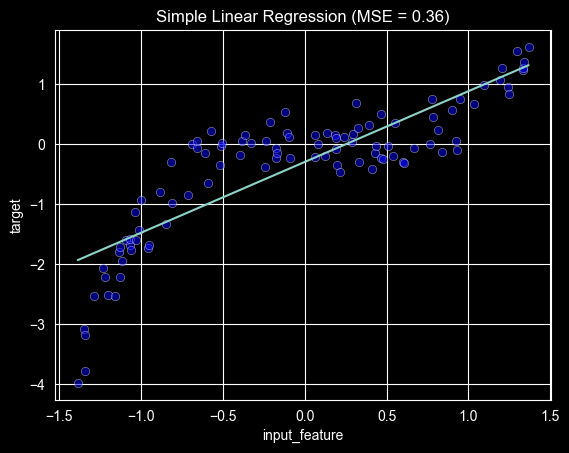

In [9]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

linear_regression = LinearRegression()
fit_score_plot_regression(linear_regression, "Simple Linear Regression")

As can be seen the model cannot handle the non-linear relationship between the data and target. There are three ways to solve this issue:
- Choose a model that can natively handle non-linearity
- Engineer a richer set of features by including expert knowledge which can be directly used by a simple linear model
- Use a "kernel" to have a locally-based decision function instead of a global linear decision function

### 1. Non-Linear Model
As an example, we use a decision tree regressor to illustrate how a model that natively handles non-linearity works.

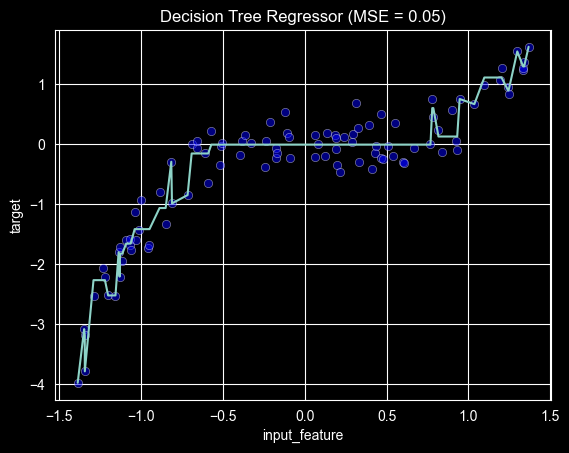

In [10]:
from sklearn.tree import DecisionTreeRegressor

tree = DecisionTreeRegressor(max_depth=5)
fit_score_plot_regression(tree, "Decision Tree Regressor")

### 2. Modify Data
We could create new features, derived from the original features, using some expert knowledge. Here, our "expert knowledge" is knowing we have a cubic and squared relationship between the data and target. So, we create two new features using `PolynominalFeatures`.

In [17]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures

polynomial_regression = make_pipeline(
    PolynomialFeatures(degree=3, include_bias=False),
    LinearRegression()
)

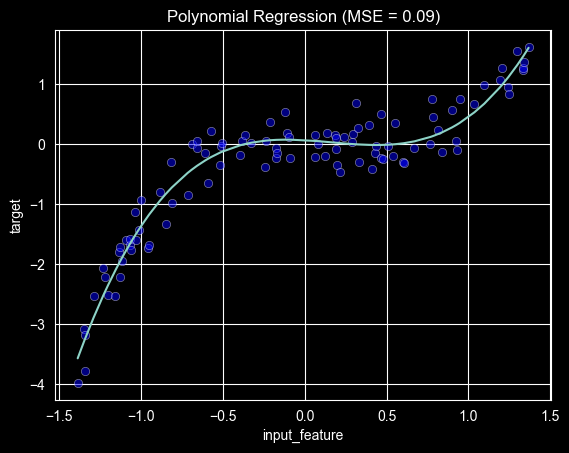

In [18]:
fit_score_plot_regression(polynomial_regression, "Polynomial Regression")

### 3. Use Kernels
Instead of learning one weight per feature, a weight is assigned to each sample. However, not all samples are used - some redundant data points of the training set are assigned a weight of 0.

In [25]:
from sklearn.svm import SVR
svr = SVR(kernel="linear")

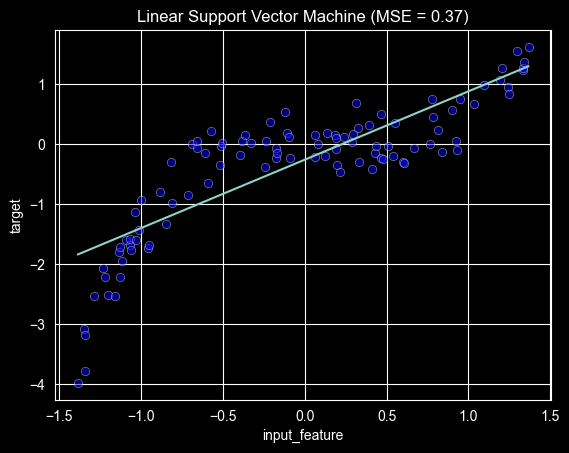

In [26]:
fit_score_plot_regression(svr, title="Linear Support Vector Machine")